##  电商网站订单数据分析

### 1.商业模式（分类）

- B2B：商家对商家（企业卖家对企业买家），交易双方都是企业，最典型的案例就是阿里巴巴，汇聚了各行业的供应商，特点是订单量一般较大。
- B2C：商家对个人（企业卖家对个人买家），例如：唯品会，聚美优品。
- B2B2C：商家对商家对个人，例如：天猫、京东。
- C2C：个人（卖家）对个人（买家），例如：淘宝、人人车。
- O2O：线上（售卖）到线下（提货），将线下的商务机会与互联网结合，让互联网成为线下交易的平台，例如：美团、饿了么。
- C2B：个人对商家（个人买家对企业卖家），先有消费者提出需求，后有商家按需求组织生产，例如：尚品宅配。

### 2.生命周期

互联网和电商刚刚兴起的时候，只要吸引用户打开网页进入店面，就会有一定比例的人下单，持续产生转化。在电商的“流量红利时代”，用“$ 店铺访客 \times 购买转化率 $”就可以估算出买家数，再用“$ 买家数 \times 客单价 $”就可以估算成交额。

随着电商的普及，拉新越来越困难（流量下滑、市场下沉、会员绑定），获客成本越来越高，用户也变得更加挑剔。电商行业不得不从“流量运营”转变为“精细化用户运营”，更加注重促成单个用户的多次购买以及老用户带动新用户的社交裂变。

### 3.核心指标

指标，具备业务含义，能够反映业务特征的数据，有几个要点：

1. 指标必须是数值，不能是文本、日期等。
2. 指标都是汇总计算出来的，单个明细数据不是指标。

- 新老用户
    - 新（老）用户数量占比
    - 新（老）用户金额占比
    
- 复购率和回购率
    - 复购率：复购（某段时间有2次及以上购买行为）用户的占比。复购率能反映用户的忠诚度，监测周期一般较长。
    - 回购率：回购率一般监测周期较短，可以反映如短期促销活动对用户的吸引力。
    
- 用户交易常用指标
    - 访问次数（PV）：一定时间内某个页面的浏览次数。
    - 访问人数（UV）：一定时间内访问某个页面的人数。
    - 加购数：将某款商品加入到购物车的用户数。
    - 收藏数：收藏某款商品的用户数。
    - GMV（总交易额、成交总额）：Gross Merchandise Volume，通常说的交易“流水”。
    - 客单价（ARPU）：“$ 总收入 / 总用户数 $” ---> ARPPU。
    - 转化率：“$ 付费用户数 / 访客数 $”。
    - 折扣率：“$ GMV / 吊牌总额 $”，其中吊牌总额为：“$ 吊牌价 \times 销量 $”。
    - 拒退量：拒收和退货的总数量。
    - 拒退额：拒收和退货的总金额。
    - 实际销售额：“$ GMV - 拒退额 $”。
    

### 4.数据预处理

1. 提取2019年的订单数据
2. 处理业务流程不符的数据（支付时间早于下单时间、支付时长超过30分钟、订单金额小于0、支付金额小于0）

In [343]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# 设置图像的显示位置，设置图像现在在当前的文档中
%matplotlib inline

#plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']  # mac
plt.rcParams['font.sans-serif'] = 'SimHei'  # window
plt.rcParams['axes.unicode_minus'] = False  # 设置负号


%config InlineBackend.figure_format = 'svg' #矢量图设置

In [290]:
# 0. 加载商品订单数据
# 1. 检查订单号有没有重复值（nunique）
# 2. 删除订单号重复的数据（保留第一项）
# 3. 提取2019年的订单数据 
# 4. 删除支付时间早于下单时间的数据
# 5. 删除支付时长超过30分钟的数据
# 6. 删除订单金额或支付金额小于0的数据

In [291]:
# 0. 加载商品订单数据
df = pd.read_excel('data\某电商网站订单数据.xlsx')

In [292]:
# 1. 检查订单号有没有重复值（nunique）
df.shape

(104557, 11)

In [293]:
df['orderID'].nunique()

104530

订单中有重复的数据

In [294]:
# 数据备份，加载数据太慢了

In [295]:
df1 = df.copy()

In [296]:
df1.shape

(104557, 11)

In [297]:
df1

,id,orderID,userID,goodsID,orderAmount,payment,chanelID,platfromType,orderTime,payTime,chargeback
0,1,sys-2018-254118088,user-157213,PR000064,272.51,272.51,渠道-0396,APP,2018-02-14 12:20:36,2019-02-28 13:38:41,否
1,2,sys-2018-263312190,user-191121,PR000583,337.93,337.93,渠道-0765,Wech atMP,2018-08-14 09:40:34,2019-01-01 14:47:14,是
2,3,sys-2018-188208169,user-211918,PR000082,905.68,891.23,渠道-0530,We c hatMP,2018-11-02 20:17:25,2019-01-19 20:06:35,否
3,4,sys-2018-203314910,user-201322,PR000302,786.27,688.88,渠道-0530,WEB,2018-11-19 10:36:39,2019-08-07 12:24:35,否
4,5,sys-2018-283989279,user-120872,PR000290,550.77,542.51,渠道-9527,APP,2018-12-26 11:19:16,2019-10-01 07:42:43,否
...,...,...,...,...,...,...,...,...,...,...,...
104552,104553,sys-2020-268392025,user-182189,PR000082,186.37,126.21,渠道-0568,Wech atMP,2020-01-01 23:30:57,2020-01-01 23:31:09,否
104553,104554,sys-2020-213140521,user-170057,PR000603,138.81,138.81,渠道-0007,APP,2020-01-01 23:31:26,2020-01-01 23:31:36,否
104554,104555,sys-2020-274536228,user-156592,PR000405,2632.27,2632.27,渠道-0985,Wech atMP,2020-01-01 23:46:56,2020-01-01 23:47:06,否
104555,104556,sys-2020-279922239,user-173702,PR000387,1206.76,1029.46,渠道-0985,APP,2020-01-01 23:47:01,2020-01-01 23:47:48,否


In [298]:
# 2. 删除订单号重复的数据（保留第一项）
#subset参数用来设置以哪些列的重复作为重复的标准，参数为列标签，如果不设置该值，则默认为以所有列作为重复的判断条件。
#keep可以设置为三个参数，默认为first
# first表示保留第一次出现的记录
# last表示保留最后一次出现的记录
# False表示把所有重复的删除
df1 = df1.drop_duplicates(subset='orderID', keep='first', inplace=False, ignore_index=False)

In [299]:
df1.shape

(104530, 11)

In [300]:
df1.head()

,id,orderID,userID,goodsID,orderAmount,payment,chanelID,platfromType,orderTime,payTime,chargeback
0,1,sys-2018-254118088,user-157213,PR000064,272.51,272.51,渠道-0396,APP,2018-02-14 12:20:36,2019-02-28 13:38:41,否
1,2,sys-2018-263312190,user-191121,PR000583,337.93,337.93,渠道-0765,Wech atMP,2018-08-14 09:40:34,2019-01-01 14:47:14,是
2,3,sys-2018-188208169,user-211918,PR000082,905.68,891.23,渠道-0530,We c hatMP,2018-11-02 20:17:25,2019-01-19 20:06:35,否
3,4,sys-2018-203314910,user-201322,PR000302,786.27,688.88,渠道-0530,WEB,2018-11-19 10:36:39,2019-08-07 12:24:35,否
4,5,sys-2018-283989279,user-120872,PR000290,550.77,542.51,渠道-9527,APP,2018-12-26 11:19:16,2019-10-01 07:42:43,否


In [301]:
# 3. 提取2019年的订单数据 

In [302]:
df2019 = df1[df1.orderID.str.contains('2019')]

In [303]:
df2019.shape

(104269, 11)

In [304]:
# 4. 删除支付时间早于下单时间的数据
df2019 = df2019[df2019['orderTime']<=df2019['payTime']]

In [305]:
# 5. 删除支付时长超过30分钟的数据
df2019 = df2019[(df2019['payTime']-df2019['orderTime']).dt.total_seconds()<1800]

In [306]:
# 6. 删除订单金额或支付金额小于0的数据
df2019 = df2019[(df2019['orderAmount']>=0) & (df2019['payment']>=0)]

In [307]:
df2019.shape

(103321, 11)

### 5.数据清洗

3. 处理渠道为空的数据（补充众数）
4. 处理平台类型字段（去掉多余的空格，保持数据一致）
5. 添加折扣字段，处理折扣大于1的字段（将支付金额修改为“订单金额*平均折扣”）

In [308]:
# 处理渠道为空的数据（补充众数）
df2019 = df2019.rename(columns = {'chanelID':'channelID','platfromType':'platformType'})

In [309]:
df2019['channelID'] = df2019['channelID'].fillna(df2019['channelID'].mode())

In [310]:
# 处理平台类型字段（去掉多余的空格，保持数据一致）
df2019['platformType'] = df2019.platformType.str.replace(r'\s','',regex=True).str.upper()

In [311]:
df2019

,id,orderID,userID,goodsID,orderAmount,payment,channelID,platformType,orderTime,payTime,chargeback
5,6,sys-2019-279103297,user-146548,PR000564,425.20,425.20,渠道-0765,WECHATMP,2019-01-01 00:12:23,2019-01-01 00:13:37,否
6,7,sys-2019-316686066,user-104210,PR000709,1764.37,1707.04,渠道-0396,WECHATMP,2019-01-01 00:23:06,2019-01-01 00:23:32,否
7,8,sys-2019-306447069,user-104863,PR000499,499.41,480.42,渠道-0007,WECHATMP,2019-01-01 01:05:50,2019-01-01 01:06:17,否
8,9,sys-2019-290267674,user-206155,PR000253,1103.00,1050.95,渠道-0330,APP,2019-01-01 01:16:12,2019-01-01 01:16:25,否
9,10,sys-2019-337079027,user-137939,PR000768,465.41,465.41,渠道-9527,ALIMP,2019-01-01 01:31:00,2019-01-01 01:31:36,否
...,...,...,...,...,...,...,...,...,...,...,...
104296,104297,sys-2019-344079195,user-182248,PR000813,831.29,766.07,渠道-0896,WECHATMP,2019-12-31 23:32:55,2019-12-31 23:33:06,否
104297,104298,sys-2019-296195955,user-143322,PR000938,1565.67,1414.89,渠道-0007,APP,2019-12-31 23:33:05,2019-12-31 23:34:36,是
104298,104299,sys-2019-382387725,user-220484,PR000782,3326.83,3273.54,渠道-0530,WEB,2019-12-31 23:37:30,2019-12-31 23:37:44,否
104299,104300,sys-2019-303891464,user-285133,PR000096,241.75,241.75,渠道-0765,WECHATMP,2019-12-31 23:38:43,2019-12-31 23:39:01,是


In [312]:
# 添加折扣字段，处理折扣大于1的字段（将支付金额修改为“订单金额*平均折扣”）
#df2019['discount'] = df2019['payment']-df2019['orderAmount'] /df2019['payment']

In [313]:
#df2019

In [314]:
#discount_mean = df2019[df2019.discount <=1 ].discount.mean()
#temp_df = df2019[df2019['discount']>1]
#temp_df['discount'] = discount_mean
#temp_df['payment'] = temp_df['orderAmount']*discount_mean
#df2019[df2019['discount']>1] = temp_df

In [315]:
df2019['discount'] = np.round(df2019.payment/df2019.orderAmount, 2)
mean_discount = round(df2019[df2019.discount <= 1].discount.mean(), 2)
df2019['payment'] = df2019.payment.where(
    df2019.discount <= 1, np.round(df2019.orderAmount*mean_discount)
)

### 6.数据分析

6. 交易总金额（GMV）、总销售额、实际销售额、退货率、客单价
7. 每月GMV及趋势分析（折线图）
8. 流量渠道来源分析（饼图）
9. 周一到周日哪天的下单量最高、每天哪个时段下单量最高（柱状图）
10. 用户复购率

In [316]:
# 6. 交易总金额（GMV）、总销售额、实际销售额、退货率、客单价

In [317]:
gmv = df2019.orderAmount.sum()
total_amount = df2019.payment.sum()
total_payment = df2019[df2019.chargeback == '否'].payment.sum()
back_rate = df2019[df2019.chargeback == '是'].orderID.count() / df2019.orderID.count()
arppu = total_payment / df2019.userID.nunique()
print(f'GMV: {gmv / 10000:.2f}万元')
print(f'总销售额: {total_amount / 10000:.2f}万元')
print(f'实际销售额: {total_payment / 10000:.2f}万元')
print(f'退货率: {round(back_rate * 100, 2)}%')
print(f'客单价: {round(arppu, 2)}元')

GMV: 10849.59万元
总销售额: 10260.53万元
实际销售额: 8891.98万元
退货率: 13.17%
客单价: 1130.81元


In [318]:
# 7. 每月GMV及趋势分析（折线图）

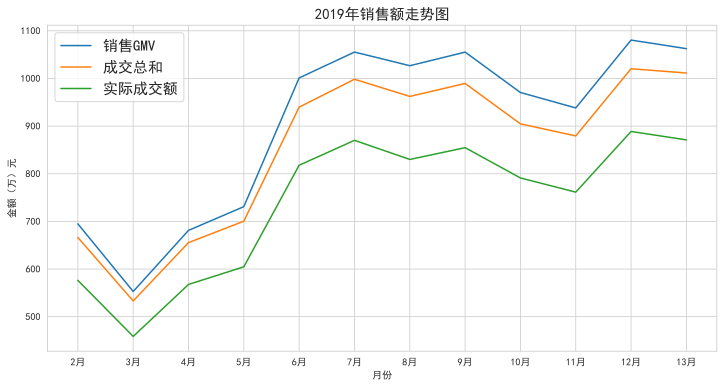

In [319]:
df2019['month'] = df2019['orderTime'].dt.month
gmv_month = round(df2019.groupby('month')['orderAmount'].sum()/10000, 2)
pay_sum_month = round(df2019.groupby('month')['payment'].sum()/10000, 2)
real_paysum_month = round(df2019[df2019['chargeback']=='否'].groupby('month')['payment'].sum()/10000, 2)
x = df2019['month'].unique()+1

plt.figure(figsize=(12,6))
x_title_label = ['{}月'.format(i) for i in x] #x轴名称
plt.xticks(x,x_title_label)
plt.xlabel('月份')
plt.ylabel('金额（万）元')
plt.title('2019年销售额走势图', fontsize=15)

plt.plot(x, gmv_month, label='销售GMV')
plt.plot(x, pay_sum_month, label='成交总和')
plt.plot(x, real_paysum_month, label='实际成交额')
plt.legend(fontsize=15)
plt.show()

通过走势图可以看到，2月份销量最低，可能是因为2月份正好出于中国春节，各快递公司都休假，而且假期中用户的在线购买欲望不高；6月份、11月份是各大电商的购物节，故销量高也属于正常情况；4月到5月销量增长迅猛，我们可以猜测是否这段时间平台的销售策略比较成功，是否有值得借鉴的部分。

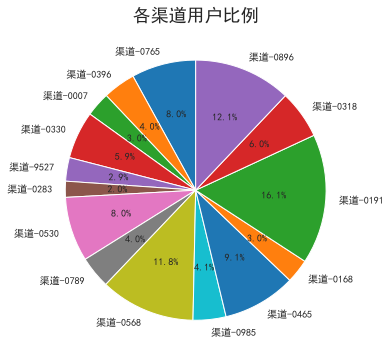

In [320]:
# 8. 流量渠道来源分析（饼图）
user_per = df2019.groupby('channelID')['userID'].count()
channel = df2019['channelID'].unique()
channel = channel[:-1]
plt.figure(figsize=(6,6))
plt.pie(user_per, labels=channel, autopct='%1.1f%%', startangle=90)
plt.title('各渠道用户比例', fontsize=18)
plt.show()


从图中可以看出渠道-0191的宣传力度很好，宣传方法值得借鉴

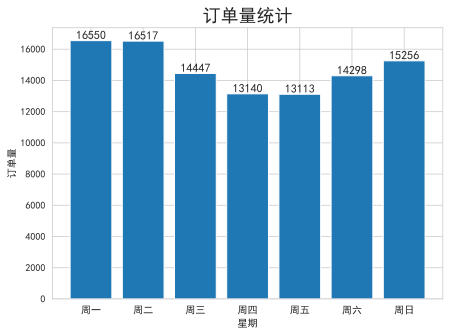

In [321]:
# 9.周一到周日哪天的下单量最高、每天哪个时段下单量最高（柱状图）
df2019['weekday'] = df2019['orderTime'].dt.dayofweek
dayofweek = df2019['weekday'].unique()
order_week = df2019.groupby('weekday')['orderID'].count()
x_label = ['周一','周二','周三','周四','周五','周六','周日']
plt.figure(figsize=(7,5))
plt.xticks(range(len(x_label)), x_label)
plt.xlabel('星期')
plt.ylabel('订单量')
plt.title('订单量统计', fontsize=18)
for a, b in zip(range(len(x_label)), order_week):
    plt.text(a, b, b, va='bottom', ha='center', fontsize=12)
plt.bar(range(len(x_label)), order_week.values)
plt.show()


In [322]:
import seaborn as sns

In [323]:
'''
strftime()方法
接收以时间元组，并返回以可读字符串表示的当地时间，格式由参数format决定。
python中时间日期格式化符号如下：%y 两位数的年份表示(00-99)
%H 24小时制小时数(0-23)
%M 分钟数(00=59)
%S 秒(00-59)
'''

'\nstrftime()方法\n接收以时间元组，并返回以可读字符串表示的当地时间，格式由参数format决定。\npython中时间日期格式化符号如下：%y 两位数的年份表示(00-99)\n%H 24小时制小时数(0-23)\n%M 分钟数(00=59)\n%S 秒(00-59)\n'

D:\ANACONDA\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(
D:\ANACONDA\lib\site-packages\matplotlib\textpath.py:74: RuntimeWarning: Glyph 19981 missing from current font.
  font.set_text(s, 0.0, flags=LOAD_NO_HINTING)
D:\ANACONDA\lib\site-packages\matplotlib\textpath.py:74: RuntimeWarning: Glyph 21516 missing from current font.
  font.set_text(s, 0.0, flags=LOAD_NO_HINTING)
D:\ANACONDA\lib\site-packages\matplotlib\textpath.py:74: RuntimeWarning: Glyph 26102 missing from current font.
  font.set_text(s, 0.0, flags=LOAD_NO_HINTING)
D:\ANACONDA\lib\site-packages\matplotlib\textpath.py:74: RuntimeWarning: Glyph 38388 missing from current font.
  font.set_text(s, 0.0, flags=LOAD_NO_HINTING)
D:\ANACONDA\lib\site-packages\matplotlib\textpath.p

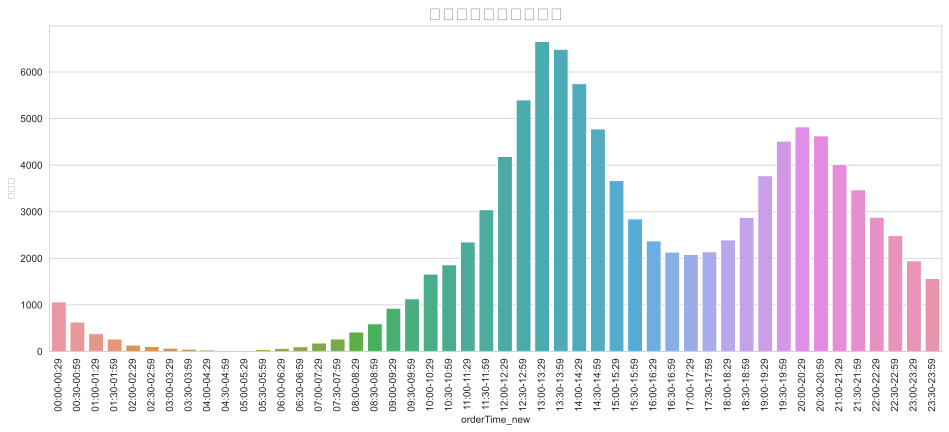

In [324]:
# 10.每天哪个时段下单量最高（柱状图）
s = df2019['orderTime'].dt.floor('30T')
#将下单时间按照时间段分类
df2019['orderTime_new'] = s.dt.strftime('%H:%M') + '-' + (s + pd.Timedelta(minutes=29)).dt.strftime('%H:%M')
time_quan = df2019.groupby('orderTime_new')['orderID'].count()
plt.figure(figsize=(16,6))
plt.xticks(rotation=90)
plt.ylabel('订单量')
plt.title('不同时间段订单量统计', fontsize=18)
sns.set_style('whitegrid')
s = sns.color_palette('husl')
sns.barplot(time_quan.index, time_quan.values)
plt.show()


从图中可以看出，12:00-13:00的订单量最多，可能是大家趁着午休时间购物，其次是19:00-22:00应该是大家下班后进行购物的比较多，如有秒杀、团购等活动，可以尽量考虑安排在这两个时间段；每天凌晨用户的下单量最低，可以考虑在这个时间段进行更新、迭代版本等工作。

D:\ANACONDA\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:title={'center':'用户复购率'}, xlabel='month', ylabel='复购率（%）'>

D:\ANACONDA\lib\site-packages\matplotlib\textpath.py:74: RuntimeWarning: Glyph 29992 missing from current font.
  font.set_text(s, 0.0, flags=LOAD_NO_HINTING)
D:\ANACONDA\lib\site-packages\matplotlib\textpath.py:74: RuntimeWarning: Glyph 25143 missing from current font.
  font.set_text(s, 0.0, flags=LOAD_NO_HINTING)
D:\ANACONDA\lib\site-packages\matplotlib\textpath.py:74: RuntimeWarning: Glyph 22797 missing from current font.
  font.set_text(s, 0.0, flags=LOAD_NO_HINTING)
D:\ANACONDA\lib\site-packages\matplotlib\textpath.py:74: RuntimeWarning: Glyph 36141 missing from current font.
  font.set_text(s, 0.0, flags=LOAD_NO_HINTING)
D:\ANACONDA\lib\site-packages\matplotlib\textpath.py:74: RuntimeWarning: Glyph 29575 missing from current font.
  font.set_text(s, 0.0, flags=LOAD_NO_HINTING)
D:\ANACONDA\lib\site-packages\matplotlib\textpath.py:74: RuntimeWarning: Glyph 65288 missing from current font.
  font.set_text(s, 0.0, flags=LOAD_NO_HINTING)
D:\ANACONDA\lib\site-packages\matplotlib\textp

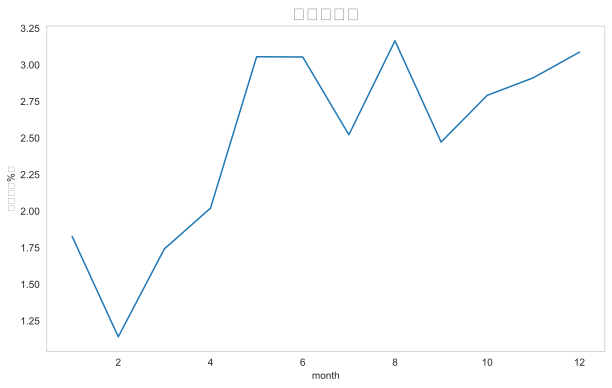

In [325]:
# 10. 用户复购率
pivoted = df2019.pivot_table(index='userID', columns='month', values='orderTime', aggfunc='count', fill_value=0)
# pivoted.sample(5)
#数据转换，消费两次以上记为1，消费1次记为0，没有消费记为NaN
pivoted_buy = pivoted.applymap(lambda x : 1 if x>1 else 0 if x==1 else np.NAN)
# pivoted_buy.sample(5)
plt.figure(figsize=(10,6))
plt.grid(alpha=0.4)
plt.ylabel('复购率（%）')
plt.title('用户复购率', fontsize=18)
sns.lineplot(pivoted.columns, pivoted_buy.sum()/pivoted_buy.count()*100)


根据走势图，我们可以看到用户的复购率低于3%，所以下一段的重点目标可以考虑如何提升用户的复购率。

### 7.数据建模

- RFM模型

   - R：Recency - 最近一次购买 ---> 低
   - F: Frequency - 购买的频次 ---> 高 
   - M: Monetary - 购买总金额 ---> 高

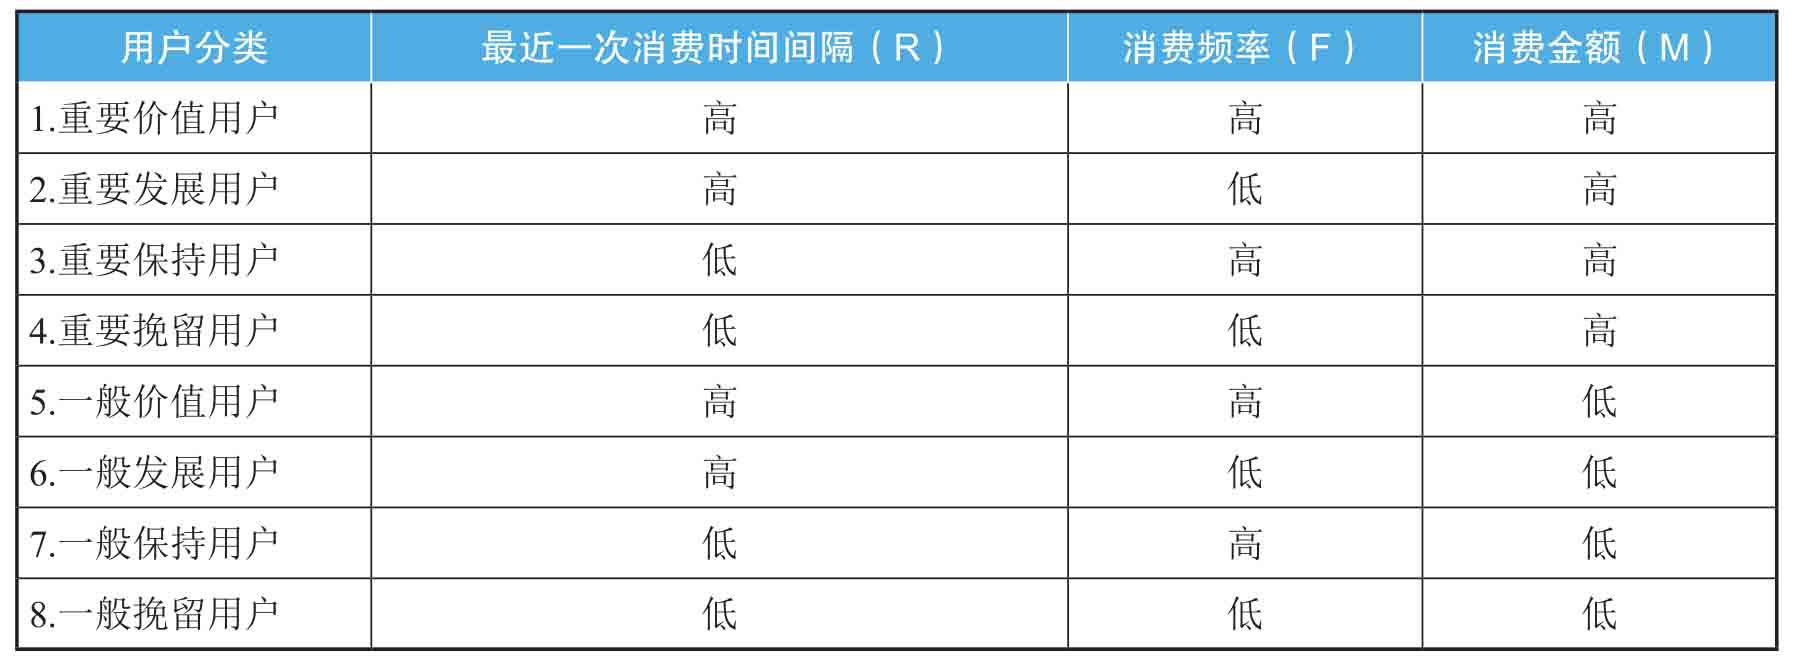

In [326]:
tags_dict = {
    "111":"重要价值客户",
    "101":"重要发展客户",
    "011":"重要保持客户",
    "001":"重要挽留客户",
    "110":"一般价值客户",
    "100":"一般发展客户",
    "010":"一般保持客户",
    "000":"一般挽留客户"
}

In [327]:
# 删除退款的订单
df2019.drop(index=df2019[df2019.chargeback == '是'].index, inplace=True)
df2019.shape

(89710, 15)

In [328]:
df2019.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 89710 entries, 5 to 104300
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   id             89710 non-null  int64         
 1   orderID        89710 non-null  object        
 2   userID         89710 non-null  object        
 3   goodsID        89710 non-null  object        
 4   orderAmount    89710 non-null  float64       
 5   payment        89710 non-null  float64       
 6   channelID      89702 non-null  object        
 7   platformType   89710 non-null  object        
 8   orderTime      89710 non-null  datetime64[ns]
 9   payTime        89710 non-null  datetime64[ns]
 10  chargeback     89710 non-null  object        
 11  discount       89710 non-null  float64       
 12  month          89710 non-null  int64         
 13  weekday        89710 non-null  int64         
 14  orderTime_new  89710 non-null  object        
dtypes: datetime64[ns](

In [329]:
df2019.userID.nunique()

70592

In [330]:
def recent_buy_date(x):
    return (df2019.payTime.max()-x.max()).days

In [331]:
res = pd.pivot_table(
    data = df2019,
    index = 'userID',
    aggfunc={
        'payTime':recent_buy_date,
        'orderID':'nunique',
        'payment':'sum'
    }
)

In [332]:
res.columns = ['F','R','M']

In [333]:
res = res.reindex(columns = ['R','F','M'])

In [334]:
res

,R,F,M
userID,,,
user-100000,79,1,1770.81
user-100003,221,1,511.59
user-100006,47,1,443.55
user-100007,351,1,2162.14
user-100008,45,1,4879.94
...,...,...,...
user-299980,74,1,389.44
user-299983,4,1,706.80
user-299989,50,2,1637.47


In [335]:
rfm = res.copy()

In [336]:
def set_value(x):
    x = x > x.median()
    return x.astype(np.int)

In [337]:
rfm = rfm.apply(set_value)

<ipython-input-336-5ba67e69db87>:3: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  return x.astype(np.int)
<ipython-input-336-5ba67e69db87>:3: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more detai

In [338]:
rfm['label'] = rfm.apply(lambda x:str(x[0])+str(x[1])+str(x[2]),axis=1)

In [339]:
rfm

,R,F,M,label
userID,,,,
user-100000,0,0,1,001
user-100003,1,0,0,100
user-100006,0,0,0,000
user-100007,1,0,1,101
user-100008,0,0,1,001
...,...,...,...,...
user-299980,0,0,0,000
user-299983,0,0,0,000
user-299989,0,1,1,011


In [340]:
tags_dict

{'111': '重要价值客户',
 '101': '重要发展客户',
 '011': '重要保持客户',
 '001': '重要挽留客户',
 '110': '一般价值客户',
 '100': '一般发展客户',
 '010': '一般保持客户',
 '000': '一般挽留客户'}

In [341]:
rfm['label'] = rfm['label'].map(tags_dict)

<AxesSubplot:>

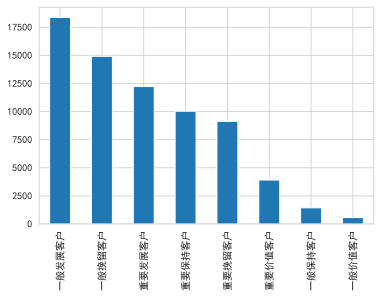

In [344]:
rfm['label'].value_counts().plot(kind = 'bar')